In [1]:
library(tidyverse)
library(lubridate)
library(TTR)
library(zoo)
library(caret)
library(xgboost)
library(readr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


The following object is masked from ‘package:httr’:

    progress



Attaching package: ‘xgboost’


The following object is masked from ‘package:dplyr’:

    slice




In [3]:
all_files <- list.files(
  path = "/kaggle/input",
  pattern = "\\.csv$",
  recursive = TRUE,
  full.names = TRUE
)
all_files <- all_files[grep("SP500_Data_10Y", all_files)]

df_master <- purrr::map_df(all_files[1:1000], function(f) {
  tryCatch({
    raw_data <- read.csv(f, skip = 3, header = FALSE,
                         fill = TRUE, stringsAsFactors = FALSE)
    
    df_temp <- raw_data[, 1:6]
    colnames(df_temp) <- c("Date_Raw", "Close", "High", "Low", "Open", "Volume")
    
    df_temp <- df_temp |>
      dplyr::mutate(
        Ticker = gsub(".csv", "", basename(f)),
        Date   = as.Date(lubridate::parse_date_time(
                   Date_Raw, orders = c("ymd", "mdy", "dmy"))),
        dplyr::across(c(Close, High, Low, Open, Volume),
                      ~ as.numeric(gsub(",", "", .)))
      ) |>
      dplyr::filter(!is.na(Date) & !is.na(Close)) |>
      dplyr::arrange(Date) |>
      dplyr::group_by(Ticker) |>
      dplyr::mutate(
        Return     = (Close - dplyr::lag(Close)) / dplyr::lag(Close),
        RSI        = as.numeric(TTR::RSI(Close, n = 14)),
        Volatility = zoo::rollapplyr(Return, 20, sd, fill = NA) * sqrt(252),
        MA10       = zoo::rollapplyr(Close, 10, mean, fill = NA),
        MA50       = zoo::rollapplyr(Close, 50, mean, fill = NA),
        Lag1       = dplyr::lag(Return, 1),
        Lag2       = dplyr::lag(Return, 2),
        Momentum   = Close / dplyr::lag(Close, 5) - 1,
        Trend      = MA10 - MA50,
        Volume_Ratio = Volume / zoo::rollapplyr(Volume, 20, mean, fill = NA)
      ) |>
      dplyr::mutate(
        Regime = dplyr::case_when(
          Volatility > quantile(Volatility, 0.75, na.rm = TRUE) ~ 2,
          Return >  0.002 ~  1,
          Return < -0.002 ~ -1,
          TRUE ~ 0
        )
      ) |>
      dplyr::ungroup() |>
      dplyr::filter(
        !is.na(Return), !is.na(RSI), !is.na(Volatility),
        !is.na(MA10), !is.na(MA50), !is.na(Lag1), !is.na(Lag2),
        !is.na(Momentum), !is.na(Trend), !is.na(Volume_Ratio)
      ) |>
      dplyr::filter(dplyr::if_all(where(is.numeric), ~ is.finite(.)))
    
    return(df_temp)
  }, error = function(e) NULL)
})

print(paste("Stocks loaded:", length(unique(df_master$Ticker))))
print(paste("Total rows:", nrow(df_master)))

[1] "Stocks loaded: 499"
[1] "Total rows: 1196097"


In [4]:
# ==============================
# CELL 3 FIXED — Correct Return Calculation
# ==============================
tickers     <- unique(df_master$Ticker)
all_results <- list()
split_date  <- as.Date("2021-01-01")

for (ticker in tickers) {
  tryCatch({
    
    df_stock <- df_master |>
      dplyr::filter(Ticker == ticker) |>
      dplyr::arrange(Date)
    
    if (nrow(df_stock) < 400) { cat("✗", ticker, "— not enough data\n"); next }
    
    train <- df_stock |> dplyr::filter(Date < split_date)
    test  <- df_stock |> dplyr::filter(Date >= split_date)
    
    # Target based on DAILY return direction (not 5-day forward)
    train <- train |>
      dplyr::mutate(Target = factor(
        ifelse(dplyr::lead(Return, 1) > 0, "Up", "Down"),
        levels = c("Down", "Up")
      ))
    test <- test |>
      dplyr::mutate(Target = factor(
        ifelse(dplyr::lead(Return, 1) > 0, "Up", "Down"),
        levels = c("Down", "Up")
      ))
    
    train <- na.omit(train)
    test  <- na.omit(test)
    
    if (nrow(train) < 150 | nrow(test) < 100) {
      cat("✗", ticker, "— split too small\n"); next
    }
    
    tune_grid <- expand.grid(
      nrounds = 100, max_depth = 4, eta = 0.05,
      gamma = 0, colsample_bytree = 0.8,
      min_child_weight = 1, subsample = 0.8
    )
    
    model <- caret::train(
      Target ~ Return + RSI + Volatility + MA10 + MA50 +
                Lag1 + Lag2 + Momentum + Trend + Volume_Ratio,
      data = train,
      method = "xgbTree",
      trControl = trainControl(method = "none"),
      tuneGrid = tune_grid,
      verbosity = 0
    )
    
    probs <- predict(model, test, type = "prob")
    test$Prob_Up <- probs$Up
    
    # Fixed threshold
    threshold <- quantile(test$Prob_Up, 0.60)
    
    test <- test |>
      dplyr::arrange(Date) |>
      dplyr::mutate(
        Signal = ifelse(Prob_Up >= threshold, "Buy", "Hold"),
        # ✅ FIX: use next day's actual Return, not forward return
        Strategy_Return = ifelse(Signal == "Buy", 
                                 dplyr::lead(Return, 1), 0),
        Strategy_Return = replace(Strategy_Return, is.na(Strategy_Return), 0),
        Return_clean    = replace(Return, is.na(Return), 0),
        Cum_Strategy    = cumprod(1 + Strategy_Return),
        Cum_Market      = cumprod(1 + Return_clean)
      )
    
    strategy_ret <- round((tail(test$Cum_Strategy, 1) - 1) * 100, 1)
    market_ret   <- round((tail(test$Cum_Market,   1) - 1) * 100, 1)
    days_in      <- sum(test$Signal == "Buy")
    
    all_results[[ticker]] <- list(
      ticker          = ticker,
      strategy_return = strategy_ret,
      market_return   = market_ret,
      beat_market     = strategy_ret > market_ret,
      latest_signal   = tail(test$Signal, 1),
      latest_price    = round(tail(test$Close, 1), 2),
      latest_prob     = round(tail(test$Prob_Up, 1), 3),
      days_in_market  = days_in,
      total_days      = nrow(test),
      test_data       = test
    )
    
    beat <- ifelse(strategy_ret > market_ret, "✓ BEAT", "  lost")
    cat(beat, ticker,
        "| Strategy:", strategy_ret, "%",
        "| Market:", market_ret, "%",
        "| In market:", round(days_in / nrow(test) * 100), "%\n")
    
  }, error = function(e) {
    cat("✗", ticker, "error:", e$message, "\n")
  })
}

cat("\n=== DONE ===\n")
cat("Stocks trained:", length(all_results), "\n")
cat("Beat market:   ", sum(unlist(lapply(all_results, function(r) r$beat_market))), "\n")

  lost A | Strategy: 16.1 % | Market: 19.5 % | In market: 40 %
  lost AAPL | Strategy: -20.8 % | Market: 110.7 % | In market: 40 %
  lost ABBV | Strategy: 16.4 % | Market: 152.7 % | In market: 40 %
✗ ABNB — split too small
  lost ABT | Strategy: 19 % | Market: 25.1 % | In market: 40 %
  lost ACGL | Strategy: 80 % | Market: 181.2 % | In market: 40 %
  lost ACN | Strategy: -22.8 % | Market: 11 % | In market: 40 %
✓ BEAT ADBE | Strategy: 0.4 % | Market: -28.9 % | In market: 40 %
✓ BEAT ADI | Strategy: 253.9 % | Market: 103.1 % | In market: 40 %
  lost ADM | Strategy: 7.5 % | Market: 32.9 % | In market: 40 %
  lost ADP | Strategy: 45.2 % | Market: 64.3 % | In market: 40 %
✓ BEAT ADSK | Strategy: -0.8 % | Market: -2 % | In market: 40 %
  lost AEE | Strategy: 22.1 % | Market: 47.2 % | In market: 40 %
  lost AEP | Strategy: 43 % | Market: 66.7 % | In market: 40 %
✓ BEAT AES | Strategy: -6.6 % | Market: -30 % | In market: 40 %
  lost AFL | Strategy: 44.9 % | Market: 179 % | In market: 40 %
  l

In [5]:
# ==============================
# CELL 4 — Summary Table
# ==============================
summary_df <- dplyr::bind_rows(lapply(all_results, function(r) {
  data.frame(
    Ticker       = r$ticker,
    Strategy_Pct = r$strategy_return,
    Market_Pct   = r$market_return,
    Difference   = r$strategy_return - r$market_return,
    Beat_Market  = r$beat_market,
    Days_In      = paste0(round(r$days_in_market / r$total_days * 100), "%"),
    Signal_Now   = r$latest_signal,
    Price_Now    = r$latest_price,
    Prob_Up      = r$latest_prob,
    stringsAsFactors = FALSE
  )
})) |> dplyr::arrange(desc(Difference))

print(as.data.frame(summary_df))

cat("\n--- SUMMARY ---\n")
cat("Stocks included:    ", nrow(summary_df), "\n")
cat("Beat market:        ", sum(summary_df$Beat_Market), "\n")
cat("Avg strategy return:", round(mean(summary_df$Strategy_Pct), 1), "%\n")
cat("Avg market return:  ", round(mean(summary_df$Market_Pct), 1), "%\n")

    Ticker Strategy_Pct Market_Pct Difference Beat_Market Days_In Signal_Now
1      TXN        445.8       23.7      422.1        TRUE     40%       Hold
2     INTC        177.2      -19.4      196.6        TRUE     40%       Hold
3     DDOG        224.6       40.5      184.1        TRUE     40%        Buy
4      BXP        170.0       -6.6      176.6        TRUE     40%        Buy
5     SWKS        103.6      -52.0      155.6        TRUE     40%        Buy
6      ADI        253.9      103.1      150.8        TRUE     40%        Buy
7     ALGN         77.1      -69.8      146.9        TRUE     40%        Buy
8     CHRW        238.3       98.0      140.3        TRUE     40%       Hold
9     CTSH        138.1       10.4      127.7        TRUE     40%       Hold
10     GPN         67.1      -60.2      127.3        TRUE     40%       Hold
11      DG         96.2      -29.9      126.1        TRUE     40%       Hold
12    META        271.0      144.9      126.1        TRUE     40%       Hold

In [6]:
# ==============================
# CELL 5 — Signals Now
# ==============================
cat("========== BUY SIGNALS NOW ==========\n")
summary_df |>
  dplyr::filter(Signal_Now == "Buy") |>
  dplyr::arrange(desc(Prob_Up)) |>
  dplyr::select(Ticker, Price_Now, Prob_Up, Strategy_Pct, Market_Pct) |>
  print()

cat("\n========== HOLD / CASH ==========\n")
summary_df |>
  dplyr::filter(Signal_Now == "Hold") |>
  dplyr::arrange(desc(Prob_Up)) |>
  dplyr::select(Ticker, Price_Now, Prob_Up, Strategy_Pct, Market_Pct) |>
  print()

========== BUY SIGNALS NOW ==========
    Ticker Price_Now Prob_Up Strategy_Pct Market_Pct
1     BIIB    169.91   0.802        -35.2      -30.6
2      NSC    291.83   0.779         -4.8       36.3
3      LYB     43.06   0.762         25.3      -33.9
4      ZBH     90.40   0.760         24.7      -37.2
5      FDS    273.39   0.750         22.5      -13.8
6     IDXX    697.10   0.746         83.9       39.5
7      NOW    153.38   0.744         80.9       39.3
8      DOW     23.04   0.744        -11.6      -45.5
9     RVTY     96.26   0.739        -28.1      -32.2
10    HUBB    434.85   0.737        101.8      201.4
11    PYPL     59.44   0.735         26.3      -74.6
12    ISRG    561.89   0.735         46.1      106.0
13     PEP    149.37   0.733         38.3       17.5
14     ADM     58.30   0.730          7.5       32.9
15     IFF     65.01   0.729        -16.1      -31.7
16    MTCH     32.61   0.721        -28.5      -77.9
17    ADBE    355.81   0.719          0.4      -28.9
18     C

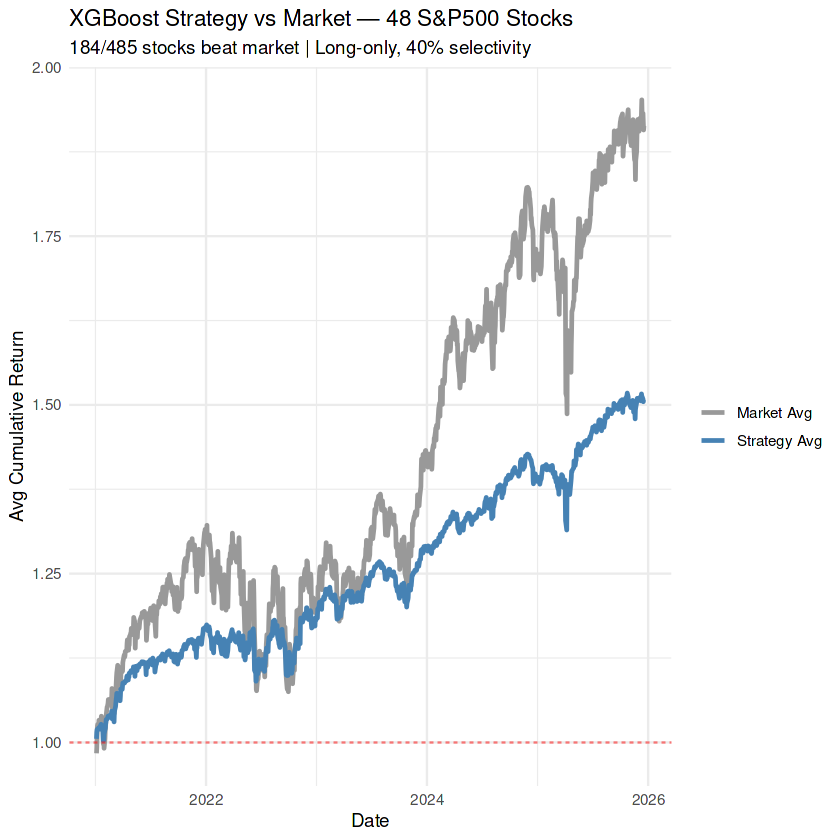

In [7]:
# ==============================
# CELL 6 — Aggregate Plot
# ==============================
all_test_data <- dplyr::bind_rows(lapply(all_results, function(r) r$test_data))

agg_plot <- all_test_data |>
  dplyr::group_by(Date) |>
  dplyr::summarise(
    Strategy = mean(Cum_Strategy, na.rm = TRUE),
    Market   = mean(Cum_Market,   na.rm = TRUE),
    .groups  = "drop"
  )

beat_count  <- sum(summary_df$Beat_Market)
total_count <- nrow(summary_df)

ggplot(agg_plot, aes(x = Date)) +
  geom_line(aes(y = Market,   color = "Market Avg"),   linewidth = 1) +
  geom_line(aes(y = Strategy, color = "Strategy Avg"), linewidth = 1) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", alpha = 0.5) +
  scale_color_manual(values = c("Market Avg"   = "gray60",
                                "Strategy Avg" = "steelblue")) +
  labs(
    title    = "XGBoost Strategy vs Market — 48 S&P500 Stocks",
    subtitle = paste0(beat_count, "/", total_count,
                      " stocks beat market | Long-only, 40% selectivity"),
    y = "Avg Cumulative Return", x = "Date", color = NULL
  ) +
  theme_minimal()

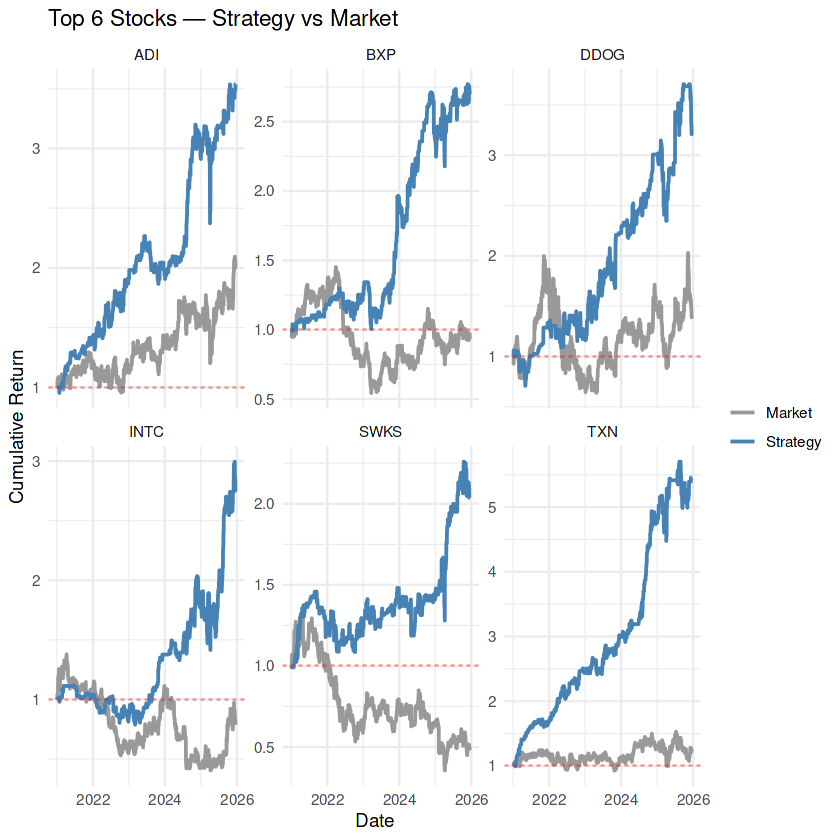

In [8]:
# ==============================
# CELL 7 — Top 6 Best Stocks Plot
# ==============================
top6 <- summary_df |>
  dplyr::arrange(desc(Difference)) |>
  dplyr::slice(1:6) |>
  dplyr::pull(Ticker)

top6_data <- dplyr::bind_rows(lapply(all_results[top6], function(r) r$test_data))

ggplot(top6_data, aes(x = Date)) +
  geom_line(aes(y = Cum_Market,   color = "Market"),   linewidth = 0.8) +
  geom_line(aes(y = Cum_Strategy, color = "Strategy"), linewidth = 0.8) +
  facet_wrap(~ Ticker, scales = "free_y", ncol = 3) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", alpha = 0.4) +
  scale_color_manual(values = c("Market"   = "gray60",
                                "Strategy" = "steelblue")) +
  labs(
    title = "Top 6 Stocks — Strategy vs Market",
    y = "Cumulative Return", x = "Date", color = NULL
  ) +
  theme_minimal()

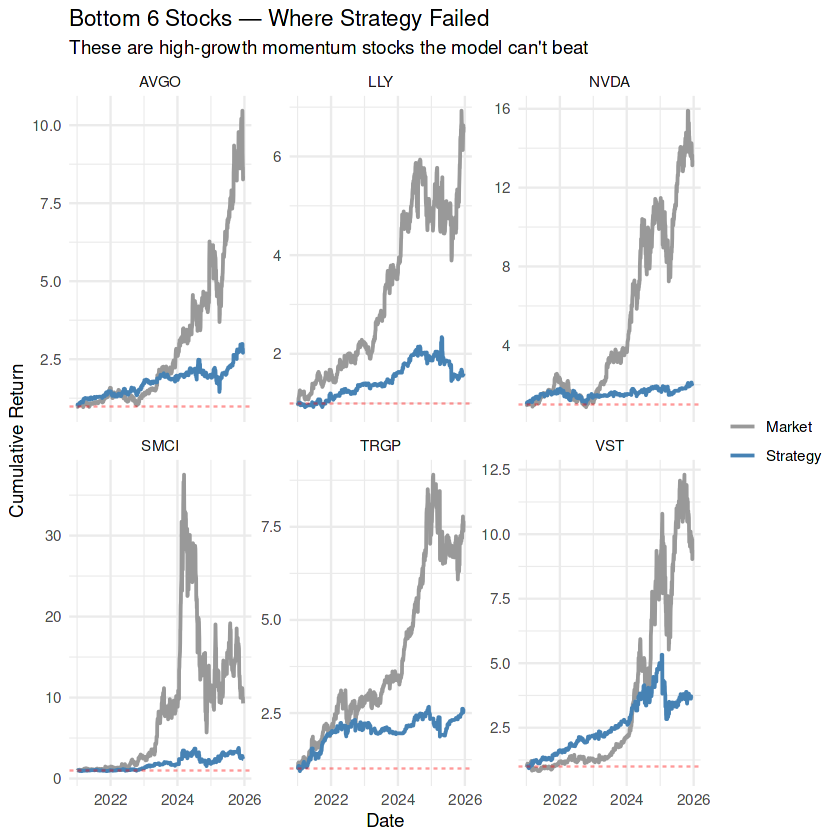

In [9]:
# ==============================
# CELL 8 — Bottom 6 Worst Stocks (for analysis)
# ==============================
bottom6 <- summary_df |>
  dplyr::arrange(Difference) |>
  dplyr::slice(1:6) |>
  dplyr::pull(Ticker)

bottom6_data <- dplyr::bind_rows(lapply(all_results[bottom6], function(r) r$test_data))

ggplot(bottom6_data, aes(x = Date)) +
  geom_line(aes(y = Cum_Market,   color = "Market"),   linewidth = 0.8) +
  geom_line(aes(y = Cum_Strategy, color = "Strategy"), linewidth = 0.8) +
  facet_wrap(~ Ticker, scales = "free_y", ncol = 3) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", alpha = 0.4) +
  scale_color_manual(values = c("Market"   = "gray60",
                                "Strategy" = "steelblue")) +
  labs(
    title    = "Bottom 6 Stocks — Where Strategy Failed",
    subtitle = "These are high-growth momentum stocks the model can't beat",
    y = "Cumulative Return", x = "Date", color = NULL
  ) +
  theme_minimal()


╔══════════════════════════════════════════╗
║       S&P 500 STOCK PREDICTOR            ║
║  Change ticker below and re-run cell     ║
╚══════════════════════════════════════════╝


  ANALYZING: ADI 

  PRICE:          $ 274.92 
  DATE:            2025-12-18 

  ══════════════════════════════════════════
  SIGNAL:          STRONG BUY ✅✅ 
  ══════════════════════════════════════════

  WHY:
   Very high confidence (71%) AND model has proven edge on ADI — beat market by +150.8% historically. 

  ──────────────────────────────────────────
  MODEL CONFIDENCE
  Probability UP:    71% 
  Probability DOWN:  29% 

  RECENT MOMENTUM
  Last 5 days:       -2.97 %
  Buy signals (20d): 20 % of days

  ──────────────────────────────────────────
  HISTORICAL RECORD ON THIS STOCK (2021-2025)
  Strategy return:  + 253.9 %
  Market return:    + 103.1 %
  Beat market:       YES ✓  (trust this signal) 
  Days in market:    40 % of trading days

  ──────────────────────────────────────────
  PRICE LEVELS


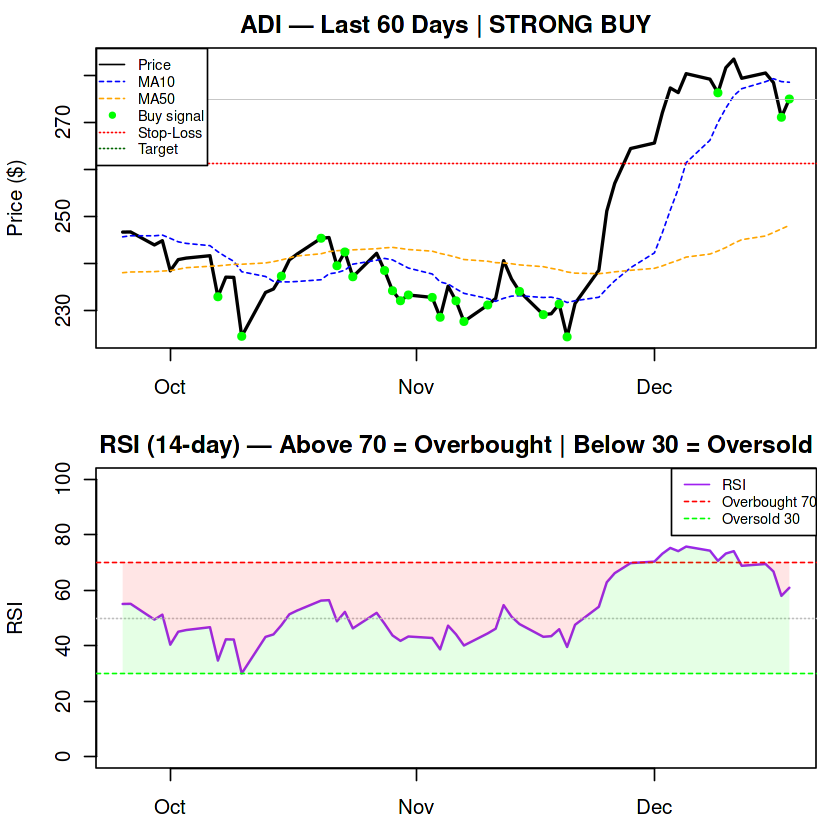

In [13]:
# ── PREDICTOR FUNCTION ──
predict_any_stock <- function(ticker_input) {
  
  ticker <- toupper(trimws(ticker_input))
  
  cat("\n")
  cat("================================================\n")
  cat("  ANALYZING:", ticker, "\n")
  cat("================================================\n")
  
  if (!ticker %in% names(all_results)) {
    cat("\n  ✗ Stock '", ticker, "' not found in trained models.\n")
    cat("  Make sure Cell 3 finished running.\n")
    cat("  Available tickers (first 10):\n")
    for (t in names(all_results)[1:10]) cat("   -", t, "\n")
    return(invisible(NULL))
  }
  
  result    <- all_results[[ticker]]
  test_data <- result$test_data
  latest    <- tail(test_data, 1)
  
  price      <- round(latest$Close, 2)
  prob_up    <- round(latest$Prob_Up, 3)
  prob_down  <- round(1 - prob_up, 3)
  
  strategy_ret <- result$strategy_return
  market_ret   <- result$market_return
  beat         <- result$beat_market
  days_in      <- round(result$days_in_market / result$total_days * 100)
  
  recent_5d    <- round(sum(tail(test_data$Return, 5), na.rm = TRUE) * 100, 2)
  buy_pct_20d  <- round(mean(tail(test_data$Signal, 20) == "Buy") * 100)
  
  stop_loss <- round(price * 0.95, 2)
  target_1  <- round(price * 1.05, 2)
  target_2  <- round(price * 1.10, 2)
  
  # Signal logic
  if (prob_up >= 0.70 & beat & strategy_ret > 0) {
    final_signal <- "STRONG BUY ✅✅"
    explanation  <- paste0(
      "Very high confidence (", scales::percent(prob_up), ") AND model has ",
      "proven edge on ", ticker, " — beat market by +",
      round(strategy_ret - market_ret, 1), "% historically."
    )
  } else if (prob_up >= 0.62 & strategy_ret > 0) {
    final_signal <- "BUY ✅"
    explanation  <- paste0(
      "Good confidence (", scales::percent(prob_up), "). ",
      "Strategy returned +", strategy_ret, "% on ", ticker, " historically."
    )
  } else if (prob_up >= 0.62 & !beat) {
    final_signal <- "BUY WITH CAUTION ⚠️"
    explanation  <- paste0(
      "Model is confident (", scales::percent(prob_up), ") but historically ",
      "this strategy did NOT beat buy-and-hold on ", ticker, ". ",
      "Market returned +", market_ret, "% vs strategy +", strategy_ret,
      "%. Consider holding instead of timing."
    )
  } else if (prob_up < 0.45) {
    final_signal <- "SELL / AVOID 🔴"
    explanation  <- paste0(
      "Model is ", scales::percent(prob_down), " confident price goes DOWN. ",
      "Do not enter new position. If you hold ", ticker,
      ", consider exiting."
    )
  } else {
    final_signal <- "HOLD / WAIT ⏸"
    explanation  <- paste0(
      "Model is uncertain (", scales::percent(prob_up), " up vs ",
      scales::percent(prob_down), " down). ",
      "Not confident enough to buy. Stay in cash and check again tomorrow."
    )
  }
  
  # Print output
  cat("\n")
  cat("  PRICE:          $", price, "\n")
  cat("  DATE:           ", as.character(latest$Date), "\n")
  cat("\n")
  cat("  ══════════════════════════════════════════\n")
  cat("  SIGNAL:         ", final_signal, "\n")
  cat("  ══════════════════════════════════════════\n")
  cat("\n")
  cat("  WHY:\n")
  cat("  ", explanation, "\n")
  cat("\n")
  cat("  ──────────────────────────────────────────\n")
  cat("  MODEL CONFIDENCE\n")
  cat("  Probability UP:   ", scales::percent(prob_up), "\n")
  cat("  Probability DOWN: ", scales::percent(prob_down), "\n")
  cat("\n")
  cat("  RECENT MOMENTUM\n")
  cat("  Last 5 days:      ", recent_5d, "%\n")
  cat("  Buy signals (20d):", buy_pct_20d, "% of days\n")
  cat("\n")
  cat("  ──────────────────────────────────────────\n")
  cat("  HISTORICAL RECORD ON THIS STOCK (2021-2025)\n")
  cat("  Strategy return:  +", strategy_ret, "%\n")
  cat("  Market return:    +", market_ret,   "%\n")
  cat("  Beat market:      ",
      ifelse(beat, "YES ✓  (trust this signal)", "NO ✗  (be cautious)"), "\n")
  cat("  Days in market:   ", days_in, "% of trading days\n")
  cat("\n")
  cat("  ──────────────────────────────────────────\n")
  cat("  PRICE LEVELS\n")
  cat("  Current price:    $", price, "\n")
  cat("  Stop-Loss (-5%):  $", stop_loss,
      "  ← exit if price drops here\n")
  cat("  Target 1  (+5%):  $", target_1, "\n")
  cat("  Target 2  (+10%): $", target_2, "\n")
  cat("  ══════════════════════════════════════════\n")
  cat("\n")
  
  # Chart
  plot_data <- tail(test_data, 60)
  
  par(mfrow = c(2,1), mar = c(3, 4, 2, 1))
  
  # Price
  plot(plot_data$Date, plot_data$Close,
       type = "l", col = "black", lwd = 2,
       main = paste0(ticker, " — Last 60 Days | ", final_signal),
       xlab = "", ylab = "Price ($)")
  
  lines(plot_data$Date, plot_data$MA10,
        col = "blue", lwd = 1, lty = 2)
  lines(plot_data$Date, plot_data$MA50,
        col = "orange", lwd = 1, lty = 2)
  
  buy_days <- plot_data[plot_data$Signal == "Buy", ]
  if (nrow(buy_days) > 0) {
    points(buy_days$Date, buy_days$Close,
           col = "green", pch = 16, cex = 0.9)
  }
  
  abline(h = stop_loss, col = "red",       lty = 3, lwd = 1)
  abline(h = target_1,  col = "darkgreen", lty = 3, lwd = 1)
  abline(h = price,     col = "gray",      lty = 1, lwd = 0.5)
  
  legend("topleft",
         legend = c("Price","MA10","MA50","Buy signal","Stop-Loss","Target"),
         col    = c("black","blue","orange","green","red","darkgreen"),
         lty    = c(1,2,2,NA,3,3),
         pch    = c(NA,NA,NA,16,NA,NA),
         cex = 0.7, bg = "white")
  
  # RSI
  plot(plot_data$Date, plot_data$RSI,
       type = "l", col = "purple", lwd = 1.5,
       main = "RSI (14-day) — Above 70 = Overbought | Below 30 = Oversold",
       xlab = "Date", ylab = "RSI", ylim = c(0,100))
  
  abline(h = 70, col = "red",   lty = 2)
  abline(h = 30, col = "green", lty = 2)
  abline(h = 50, col = "gray",  lty = 3)
  
  polygon(c(plot_data$Date, rev(plot_data$Date)),
          c(pmin(plot_data$RSI, 70), rep(70, nrow(plot_data))),
          col = rgb(1,0,0,0.1), border = NA)
  polygon(c(plot_data$Date, rev(plot_data$Date)),
          c(pmax(plot_data$RSI, 30), rep(30, nrow(plot_data))),
          col = rgb(0,1,0,0.1), border = NA)
  
  legend("topright",
         legend = c("RSI","Overbought 70","Oversold 30"),
         col    = c("purple","red","green"),
         lty    = c(1,2,2), cex = 0.7, bg = "white")
  
  par(mfrow = c(1,1))
  
  return(invisible(list(
    ticker    = ticker,
    signal    = final_signal,
    price     = price,
    prob_up   = prob_up,
    stop_loss = stop_loss,
    target    = target_1
  )))
}

# ── INTERACTIVE INPUT — KAGGLE COMPATIBLE ──
cat("\n")
cat("╔══════════════════════════════════════════╗\n")
cat("║       S&P 500 STOCK PREDICTOR            ║\n")
cat("║  Change ticker below and re-run cell     ║\n")
cat("╚══════════════════════════════════════════╝\n\n")

# ======================================
# ► TYPE YOUR STOCK TICKER HERE ◄
# ======================================
my_ticker <- "ADI"
# ======================================

# Special commands:
# my_ticker <- "best"   → shows top 15 Buy signals
# my_ticker <- "list"   → shows all available tickers

if (tolower(my_ticker) == "best") {
  cat("\n========== TOP BUY SIGNALS RIGHT NOW ==========\n")
  summary_df |>
    dplyr::filter(Signal_Now == "Buy",
                  Beat_Market == TRUE,
                  Strategy_Pct > 0) |>
    dplyr::arrange(desc(Prob_Up)) |>
    dplyr::slice(1:15) |>
    dplyr::select(Ticker, Price_Now, Prob_Up,
                  Strategy_Pct, Market_Pct) |>
    print(row.names = FALSE)
  cat("================================================\n")
  
} else if (tolower(my_ticker) == "list") {
  cat("\nAll available tickers:\n")
  cat(paste(names(all_results), collapse = "  "), "\n")
  
} else {
  predict_any_stock(my_ticker)
}

In [ ]:
########################Another Way

###Another Way

In [1]:
# Install packages you don't have yet
install.packages(c("tidyquant", "xgboost", "caret", "TTR", 
                   "zoo", "tidyverse", "lubridate"), 
                 quiet = TRUE)

library(tidyquant)   # live stock data (replaces your Kaggle CSVs)
library(xgboost)
library(caret)
library(TTR)
library(zoo)
library(tidyverse)
library(lubridate)

print("Libraries loaded ✓")

Warning message:
“unable to access index for repository http://cran.rstudio.com/src/contrib:
  cannot open URL 'http://cran.rstudio.com/src/contrib/PACKAGES'”
Warning message:
“packages ‘tidyquant’, ‘xgboost’, ‘caret’, ‘TTR’, ‘zoo’, ‘tidyverse’, ‘lubridate’ are not available for this version of R

Versions of these packages for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

── Attaching core tidyquant packages ─────────────────────── tidyquant 1.0.10 ──
✔ PerformanceAnalytics 2.0.8      ✔ TTR                  0.24.4
✔ quantmod             0.4.26     ✔ xts                  0.14.1
── Conflicts ────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ PerformanceAn

[1] "Libraries loaded ✓"


In [7]:
engineer_features <- function(df) {
  # df must have columns: date, open, high, low, close, volume
  
  df <- df |>
    dplyr::arrange(date) |>
    dplyr::mutate(
      
      # Returns
      Return      = (close - lag(close)) / lag(close),
      Lag1        = lag(Return, 1),
      Lag2        = lag(Return, 2),
      Lag5        = lag(Return, 5),
      
      # Moving averages
      MA10        = zoo::rollapplyr(close, 10,  mean, fill = NA),
      MA50        = zoo::rollapplyr(close, 50,  mean, fill = NA),
      MA200       = zoo::rollapplyr(close, 200, mean, fill = NA),
      Trend       = MA10 - MA50,
      
      # Momentum
      Momentum5   = close / lag(close, 5)  - 1,
      Momentum10  = close / lag(close, 10) - 1,
      Momentum20  = close / lag(close, 20) - 1,
      
      # Volatility
      Volatility  = zoo::rollapplyr(Return, 20, sd, fill = NA) * sqrt(252),
      Vol_Ratio   = Volatility / zoo::rollapplyr(Volatility, 60, mean, fill = NA),
      
      # RSI
      RSI         = as.numeric(TTR::RSI(close, n = 14)),
      
      # Volume
      Volume_Ratio = volume / zoo::rollapplyr(volume, 20, mean, fill = NA),
      Volume_Trend = volume / lag(volume, 5) - 1,
      
      # Price position within 20-day range (0 = at low, 1 = at high)
      High20      = zoo::rollapplyr(high, 20, max, fill = NA),
      Low20       = zoo::rollapplyr(low,  20, min, fill = NA),
      Price_Position = (close - Low20) / (High20 - Low20 + 1e-8),
      
      # Candle body
      Body        = (close - open) / open,
      Upper_Wick  = (high  - pmax(close, open)) / open,
      Lower_Wick  = (pmin(close, open) - low)   / open,
      
      # Regime
      Regime = dplyr::case_when(
        Volatility > quantile(Volatility, 0.75, na.rm = TRUE) ~  2,
        Return >  0.002 ~  1,
        Return < -0.002 ~ -1,
        TRUE ~ 0
      ),
      
      # Target: will next day close be higher?
      Target         = factor(ifelse(lead(close, 1) > close, "Up", "Down"),
                              levels = c("Down", "Up")),
      Forward_Return = lead(Return, 1)
      
    ) |>
    dplyr::filter(
      dplyr::if_all(where(is.numeric), ~ is.finite(.)),
      !is.na(Target)
    )
  
  return(df)
}

print("Feature engineering function ready ✓")

[1] "Feature engineering function ready ✓"


In [8]:
FEATURE_COLS <- c(
  "Return", "Lag1", "Lag2", "Lag5",
  "MA10", "MA50", "Trend",
  "Momentum5", "Momentum10", "Momentum20",
  "Volatility", "Vol_Ratio",
  "RSI", "Volume_Ratio", "Volume_Trend",
  "Price_Position", "Body", "Upper_Wick", "Lower_Wick",
  "Regime"
)

train_model <- function(ticker, years = 5) {
  
  cat("Training", ticker, "...\n")
  
  # Download live data via tidyquant (replaces Kaggle CSV)
  raw <- tryCatch({
    tidyquant::tq_get(ticker,
                      from = Sys.Date() - (years * 365),
                      to   = Sys.Date())
  }, error = function(e) NULL)
  
  if (is.null(raw) || nrow(raw) < 300) {
    cat("  ✗", ticker, "— not enough data\n")
    return(NULL)
  }
  
  # Engineer features
  df <- engineer_features(raw)
  
  if (nrow(df) < 200) {
    cat("  ✗", ticker, "— too few rows after feature engineering\n")
    return(NULL)
  }
  
  # 80/20 split
  split_idx <- floor(nrow(df) * 0.80)
  train_df  <- df[1:split_idx, ]
  test_df   <- df[(split_idx + 1):nrow(df), ]
  
  tune_grid <- expand.grid(
    nrounds          = 200,
    max_depth        = 4,
    eta              = 0.05,
    gamma            = 0.5,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    subsample        = 0.8
  )
  
  model <- caret::train(
    x         = train_df[, FEATURE_COLS],
    y         = train_df$Target,
    method    = "xgbTree",
    trControl = trainControl(method = "none"),
    tuneGrid  = tune_grid,
    verbosity = 0
  )
  
  # Evaluate on test
  preds    <- predict(model, test_df[, FEATURE_COLS])
  accuracy <- mean(preds == test_df$Target, na.rm = TRUE)
  
  # Add probabilities
  probs          <- predict(model, test_df[, FEATURE_COLS], type = "prob")
  test_df$Prob_Up   <- probs$Up
  test_df$Prob_Down <- probs$Down
  
  cat("  ✓", ticker, 
      "| Accuracy:", round(accuracy * 100, 1), "%",
      "| Test rows:", nrow(test_df), "\n")
  
  return(list(
    model    = model,
    test_df  = test_df,
    accuracy = accuracy,
    ticker   = ticker
  ))
}

print("Train function ready ✓")

[1] "Train function ready ✓"


In [9]:
predict_stock <- function(ticker, 
                          trained_model = NULL, 
                          stop_loss_pct = 0.05,
                          years = 5) {
  
  # Download fresh data
  raw <- tryCatch({
    tidyquant::tq_get(ticker,
                      from = Sys.Date() - (years * 365),
                      to   = Sys.Date())
  }, error = function(e) NULL)
  
  if (is.null(raw) || nrow(raw) < 100) {
    cat("Cannot find data for", ticker, "\n")
    return(NULL)
  }
  
  # Engineer features
  df <- engineer_features(raw)
  
  # Train fresh model if none provided
  if (is.null(trained_model)) {
    result <- train_model(ticker, years = years)
    if (is.null(result)) return(NULL)
    trained_model <- result$model
  }
  
  # Get latest row (today)
  latest       <- df[nrow(df), FEATURE_COLS]
  latest_date  <- df$date[nrow(df)]
  latest_close <- raw$close[nrow(raw)]
  
  # Predict
  probs     <- predict(trained_model, latest, type = "prob")
  prob_up   <- round(probs$Up,   3)
  prob_down <- round(probs$Down, 3)
  
  # Recent 5-day performance for stop-loss check
  recent_5d <- sum(tail(df$Return, 5), na.rm = TRUE)
  
  # Signal logic
  if (prob_up >= 0.62) {
    signal <- "BUY"
    emoji  <- "✅"
    action <- "Enter long position — model confident price goes UP"
    
  } else if (prob_down >= 0.60) {
    signal <- "SELL"
    emoji  <- "🔴"
    action <- "Short sell OR exit existing position — model confident price goes DOWN"
    
  } else if (recent_5d < -stop_loss_pct) {
    signal <- "SELL"
    emoji  <- "🛑"
    action <- paste0("STOP LOSS — dropped ", round(recent_5d * 100, 1), "% in 5 days")
    
  } else {
    signal <- "HOLD"
    emoji  <- "⏸"
    action <- "Uncertain — stay in cash, wait for clearer signal"
  }
  
  stop_loss_price <- round(latest_close * (1 - stop_loss_pct), 2)
  target_price    <- round(latest_close * (1 + 0.05), 2)
  
  # Print result
  cat("\n")
  cat("==================================================\n")
  cat("  STOCK:      ", ticker, "\n")
  cat("  DATE:       ", as.character(latest_date), "\n")
  cat("  PRICE:      $", round(latest_close, 2), "\n")
  cat("--------------------------------------------------\n")
  cat("  SIGNAL:     ", emoji, signal, "\n")
  cat("  ACTION:     ", action, "\n")
  cat("--------------------------------------------------\n")
  cat("  Prob UP:    ", scales::percent(prob_up), "\n")
  cat("  Prob DOWN:  ", scales::percent(prob_down), "\n")
  cat("  5-day perf: ", scales::percent(round(recent_5d, 4)), "\n")
  cat("--------------------------------------------------\n")
  cat("  Stop-Loss:  $", stop_loss_price, "(-5%)\n")
  cat("  Target:     $", target_price, "(+5%)\n")
  cat("==================================================\n")
  
  return(list(
    ticker       = ticker,
    date         = latest_date,
    price        = latest_close,
    signal       = signal,
    action       = action,
    prob_up      = prob_up,
    prob_down    = prob_down,
    stop_loss    = stop_loss_price,
    target       = target_price,
    model        = trained_model,
    df           = df,
    raw          = raw
  ))
}

print("Prediction function ready ✓")

[1] "Prediction function ready ✓"


In [10]:
plot_prediction <- function(result) {
  
  df    <- result$df
  ticker <- result$ticker
  
  # Last 6 months only
  df_plot <- df |> dplyr::filter(date >= Sys.Date() - 180)
  
  signal_color <- dplyr::case_when(
    result$signal == "BUY"  ~ "green",
    result$signal == "SELL" ~ "red",
    TRUE ~ "gray"
  )
  
  p <- ggplot(df_plot, aes(x = date)) +
    
    # Price line
    geom_line(aes(y = close), color = "black", linewidth = 1) +
    
    # Moving averages
    geom_line(aes(y = MA10), color = "blue",
              linestyle = "dashed", linewidth = 0.7, alpha = 0.7) +
    geom_line(aes(y = MA50), color = "orange",
              linetype = "dashed", linewidth = 0.7, alpha = 0.7) +
    
    # Stop-loss and target lines
    geom_hline(yintercept = result$stop_loss,
               color = "red",   linetype = "dotted", alpha = 0.6) +
    geom_hline(yintercept = result$target,
               color = "green", linetype = "dotted", alpha = 0.6) +
    
    # Signal dot on latest date
    geom_point(data = data.frame(date  = result$date,
                                  close = result$price),
               aes(x = date, y = close),
               color = signal_color, size = 5, shape = 17) +
    
    # Labels
    annotate("text", x = max(df_plot$date),
             y = result$stop_loss * 0.998,
             label = paste0("Stop-Loss $", result$stop_loss),
             color = "red", hjust = 1, size = 3) +
    
    annotate("text", x = max(df_plot$date),
             y = result$target * 1.002,
             label = paste0("Target $", result$target),
             color = "darkgreen", hjust = 1, size = 3) +
    
    labs(
      title    = paste0(ticker, " — Signal: ", result$signal,
                        " | Prob Up: ", scales::percent(result$prob_up)),
      subtitle = paste0("Price: $", round(result$price, 2),
                        " | Action: ", result$action),
      x = "Date", y = "Price ($)"
    ) +
    theme_minimal() +
    theme(plot.title    = element_text(size = 14, face = "bold"),
          plot.subtitle = element_text(size = 10, color = "gray40"))
  
  print(p)
}

print("Chart function ready ✓")

[1] "Chart function ready ✓"


Training AAPL ...


Warning message:
“Setting row names on a tibble is deprecated.”


  ✓ AAPL | Accuracy: 49.3 % | Test rows: 211 

  STOCK:       AAPL 
  DATE:        2026-04-24 
  PRICE:      $ 267.61 
--------------------------------------------------
  SIGNAL:      ⏸ HOLD 
  ACTION:      Uncertain — stay in cash, wait for clearer signal 
--------------------------------------------------
  Prob UP:     44% 
  Prob DOWN:   56% 
  5-day perf:  0% 
--------------------------------------------------
  Stop-Loss:  $ 254.23 (-5%)
  Target:     $ 280.99 (+5%)


Warning message in geom_line(aes(y = MA10), color = "blue", linestyle = "dashed", :
“Ignoring unknown parameters: `linestyle`”


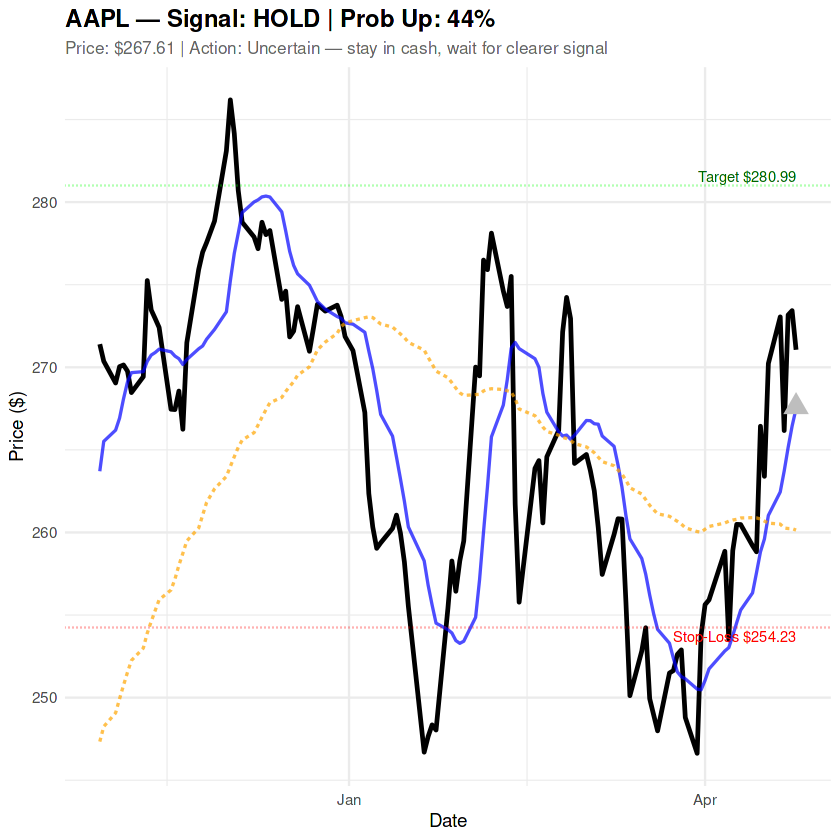

In [11]:
# ======================================
# INPUT ANY STOCK TICKER HERE
# ======================================
ticker <- "AAPL"   # try: "TSLA", "NVDA", "MSFT", "AMZN", "GOOGL"
# ======================================

result <- predict_stock(ticker, stop_loss_pct = 0.05)

if (!is.null(result)) {
  plot_prediction(result)
}

In [12]:
watchlist <- c("AAPL", "MSFT", "NVDA", "TSLA", "AMZN",
               "GOOGL", "META", "JPM", "V", "JNJ")

scan_results <- list()

for (t in watchlist) {
  res <- predict_stock(t, stop_loss_pct = 0.05)
  if (!is.null(res)) {
    scan_results[[t]] <- data.frame(
      Ticker    = res$ticker,
      Price     = paste0("$", round(res$price, 2)),
      Signal    = res$signal,
      Prob_Up   = scales::percent(res$prob_up),
      Prob_Down = scales::percent(res$prob_down),
      Stop_Loss = paste0("$", res$stop_loss),
      Target    = paste0("$", res$target)
    )
  }
}

# Summary table
summary_table <- dplyr::bind_rows(scan_results) |>
  dplyr::arrange(Signal)

cat("\n========== MARKET SCANNER ==========\n")
print(summary_table, row.names = FALSE)

cat("\n✅ BUY: ", sum(summary_table$Signal == "BUY"))
cat("\n🔴 SELL:", sum(summary_table$Signal == "SELL"))
cat("\n⏸ HOLD:", sum(summary_table$Signal == "HOLD"), "\n")

Training AAPL ...


Warning message:
“Setting row names on a tibble is deprecated.”


  ✓ AAPL | Accuracy: 49.8 % | Test rows: 211 

  STOCK:       AAPL 
  DATE:        2026-04-24 
  PRICE:      $ 267.61 
--------------------------------------------------
  SIGNAL:      ⏸ HOLD 
  ACTION:      Uncertain — stay in cash, wait for clearer signal 
--------------------------------------------------
  Prob UP:     41% 
  Prob DOWN:   59% 
  5-day perf:  0% 
--------------------------------------------------
  Stop-Loss:  $ 254.23 (-5%)
  Target:     $ 280.99 (+5%)
Training MSFT ...


Warning message:
“Setting row names on a tibble is deprecated.”


  ✓ MSFT | Accuracy: 56.4 % | Test rows: 211 

  STOCK:       MSFT 
  DATE:        2026-04-24 
  PRICE:      $ 424.82 
--------------------------------------------------
  SIGNAL:      🔴 SELL 
  ACTION:      Short sell OR exit existing position — model confident price goes DOWN 
--------------------------------------------------
  Prob UP:     36% 
  Prob DOWN:   64% 
  5-day perf:  1% 
--------------------------------------------------
  Stop-Loss:  $ 403.58 (-5%)
  Target:     $ 446.06 (+5%)
Training NVDA ...


...

  ✓ JPM | Accuracy: 56.9 % | Test rows: 211 

  STOCK:       JPM 
  DATE:        2026-04-24 
  PRICE:      $ 311.63 
--------------------------------------------------
  SIGNAL:      ⏸ HOLD 
  ACTION:      Uncertain — stay in cash, wait for clearer signal 
--------------------------------------------------
  Prob UP:     61% 
  Prob DOWN:   39% 
  5-day perf:  -1% 
--------------------------------------------------
  Stop-Loss:  $ 296.05 (-5%)
  Target:     $ 327.21 (+5%)
Training V ...


Warning message:
“Setting row names on a tibble is deprecated.”


  ✓ V | Accuracy: 47.4 % | Test rows: 211 

  STOCK:       V 
  DATE:        2026-04-24 
  PRICE:      $ 309.65 
--------------------------------------------------
  SIGNAL:      ⏸ HOLD 
  ACTION:      Uncertain — stay in cash, wait for clearer signal 
--------------------------------------------------
  Prob UP:     49% 
  Prob DOWN:   51% 
  5-day perf:  -2% 
--------------------------------------------------
  Stop-Loss:  $ 294.17 (-5%)
  Target:     $ 325.13 (+5%)
Training JNJ ...


Warning message:
“Setting row names on a tibble is deprecated.”


  ✓ JNJ | Accuracy: 46 % | Test rows: 211 

  STOCK:       JNJ 
  DATE:        2026-04-24 
  PRICE:      $ 225.34 
--------------------------------------------------
  SIGNAL:      🔴 SELL 
  ACTION:      Short sell OR exit existing position — model confident price goes DOWN 
--------------------------------------------------
  Prob UP:     27% 
  Prob DOWN:   73% 
  5-day perf:  -3% 
--------------------------------------------------
  Stop-Loss:  $ 214.07 (-5%)
  Target:     $ 236.61 (+5%)

========== MARKET SCANNER ==========
 Ticker   Price Signal Prob_Up Prob_Down Stop_Loss  Target
   AAPL $267.61   HOLD     41%       59%   $254.23 $280.99
   META $678.62   HOLD     49%       51%   $644.69 $712.55
    JPM $311.63   HOLD     61%       39%   $296.05 $327.21
      V $309.65   HOLD     49%       51%   $294.17 $325.13
   MSFT $424.82   SELL     36%       64%   $403.58 $446.06
   NVDA $216.61   SELL     38%       62%   $205.78 $227.44
   TSLA $378.67   SELL     14%       86%   $359.74  $